# Unsteady Time Integration

implement Forward Euler and AB2
$$\frac{du}{dt} = -u, \quad u(0)=1 \quad \text{(exact solution: } u=e^{-t}\text{)}$$
use Δt = 0.5 over t ∈ [0, 5]

## import library

In [133]:
import numpy as np
import matplotlib.pyplot as plt

## Time setup

In [134]:
dt = 0.5
t = np.arange(0, 5+dt, dt)

print("Time vector:", t)

Time vector: [0.  0.5 1.  1.5 2.  2.5 3.  3.5 4.  4.5 5. ]


## plot exact solution

Exact solution: [1.         0.60653066 0.36787944 0.22313016 0.13533528 0.082085
 0.04978707 0.03019738 0.01831564 0.011109   0.00673795]


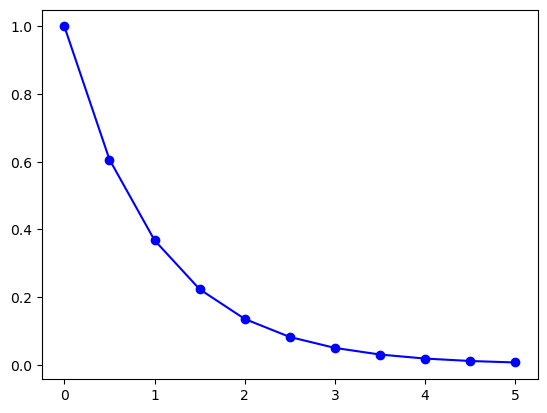

In [135]:
# exact solution
u_exact = np.exp(-t)
print("Exact solution:", u_exact)
plt.plot(t, u_exact, label='Exact Solution', color='b', marker='o')

## Function of currrent term
Function to compute the $$F(u^n)$$ for the ODE $$\frac{du}{dt} = -u$$

In [136]:
def F(u):
    return -u

## Forward Euler

Forward Euler solution: [1.000000e+00 5.000000e-01 2.500000e-01 1.250000e-01 6.250000e-02
 3.125000e-02 1.562500e-02 7.812500e-03 3.906250e-03 1.953125e-03
 9.765625e-04]


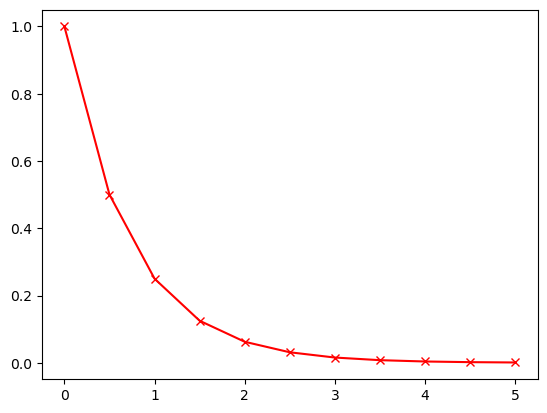

In [137]:
# Forward Euler method
u_forward_euler = np.zeros_like(t)
u_forward_euler[0] = 1.0  # initial condition
for n in range(len(t)-1):
    u_forward_euler[n+1] = u_forward_euler[n] + dt * F(u_forward_euler[n])

print("Forward Euler solution:", u_forward_euler)
plt.plot(t, u_forward_euler, label='Forward Euler', color='r', marker='x')

## Adams-Bashforth 2

Adams-Bashforth 2nd order solution: [1.         0.25       0.3125     0.140625   0.11328125 0.06347656
 0.04418945 0.0269165  0.01777649 0.01117325 0.00723743]


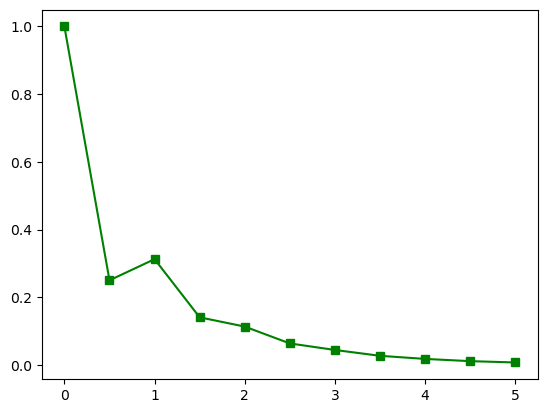

In [138]:
u_ab2 = np.zeros_like(t)
u_ab2[0] = 1.0  # initial condition
# Adams-Bashforth 2nd order method
for n in range(len(t)-1):
    u_ab2[n+1] = u_ab2[n] + dt * (1.5 * F(u_ab2[n]) - 0.5 * F(u_ab2[n-1]))

print("Adams-Bashforth 2nd order solution:", u_ab2)
plt.plot(t, u_ab2, label='Adams-Bashforth 2nd Order', color='g', marker='s')

## Compare the results

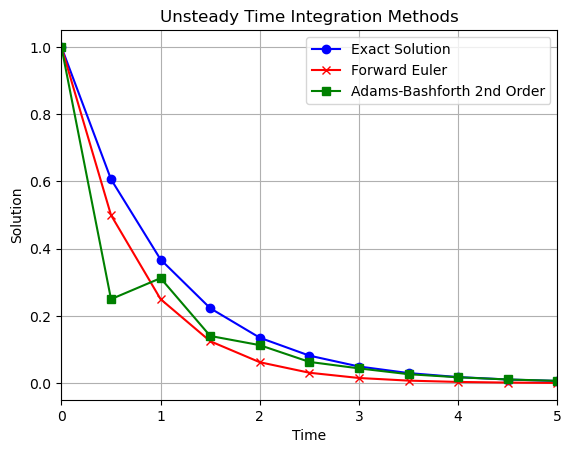

In [139]:
plt.xlabel('Time')
plt.ylabel('Solution')
plt.title('Unsteady Time Integration Methods')
plt.xlim([0, 5])
plt.plot(t, u_exact, label='Exact Solution', color='b', marker='o')
plt.plot(t, u_forward_euler, label='Forward Euler', color='r', marker='x')
plt.plot(t, u_ab2, label='Adams-Bashforth 2nd Order', color='g', marker='s')
plt.legend()
plt.grid()